In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\loneo\OneDrive\Documents\ev-charging-demand-segmentation\data\processed\ev_charging_cleaned.csv")

C:\Users\loneo\AppData\Local\Temp\ipykernel_12364\640505923.py:1: DtypeWarning: Columns (0: User ID, 1: County, 2: Model Number) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r"C:\Users\loneo\OneDrive\Documents\ev-charging-demand-segmentation\data\processed\ev_charging_cleaned.csv")


In [3]:
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])
df['Transaction Date (Pacific Time)'] = pd.to_datetime(df['Transaction Date (Pacific Time)'])

df['Total Duration (hh:mm:ss)'] = pd.to_timedelta(df['Total Duration (hh:mm:ss)'])

df['Charging Time (hh:mm:ss)'] = pd.to_timedelta(df['Charging Time (hh:mm:ss)'])

In [4]:
df['Start Date Year'] = pd.to_datetime(df['Start Date']).dt.year
df['Start Date Month'] = pd.to_datetime(df['Start Date']).dt.month
df['Start Date Date'] = pd.to_datetime(df['Start Date']).dt.date
df['Start Date Hour'] = pd.to_datetime(df['Start Date']).dt.hour
df['Start Date Dayofweek'] = pd.to_datetime(df['Start Date']).dt.dayofweek

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 259366 entries, 0 to 259365
Data columns (total 38 columns):
 #   Column                           Non-Null Count   Dtype          
---  ------                           --------------   -----          
 0   Station Name                     259366 non-null  str            
 1   MAC Address                      259366 non-null  str            
 2   Org Name                         259366 non-null  str            
 3   Start Date                       259366 non-null  datetime64[us] 
 4   Start Time Zone                  259366 non-null  str            
 5   End Date                         259366 non-null  datetime64[us] 
 6   End Time Zone                    259366 non-null  str            
 7   Transaction Date (Pacific Time)  259157 non-null  datetime64[us] 
 8   Total Duration (hh:mm:ss)        259366 non-null  timedelta64[us]
 9   Charging Time (hh:mm:ss)         259366 non-null  timedelta64[us]
 10  Energy (kWh)                     259366 non

In [6]:
dz=df.groupby('Station Name').agg({'Energy (kWh)': ['count','mean','sum'],'Charging Time (hh:mm:ss)': 'mean','Total Duration (hh:mm:ss)': 'mean','Start Date':'count'})

dx=pd.DataFrame()
dx['total_sessions']=dz['Start Date']['count']
dx['avg energy']=dz['Energy (kWh)']['mean']
dx['total_energy']=dz['Energy (kWh)']['sum']
dx['avg_charging_time']=dz['Charging Time (hh:mm:ss)']['mean']
dx['avg_total_duration']=dz['Total Duration (hh:mm:ss)']['mean']

active_days = (df.groupby('Station Name')['Start Date Date'].nunique())
dx['active_days'] = active_days
dx['sessions_per_day'] = (dx['total_sessions'] / dx['active_days'])

weekend_sessions = (df[df['Start Date Dayofweek'].isin([5, 6])].groupby('Station Name').size())

dx['weekend_sessions'] = weekend_sessions
dx['weekend_sessions'] = dx['weekend_sessions'].fillna(0)
dx['weekend_ratio'] = (dx['weekend_sessions'] / dx['total_sessions'])

peak_df = df[df['Start Date Hour'].between(8, 18)]
peak_sessions = (peak_df.groupby('Station Name').size())

dx['peak_sessions'] = peak_sessions
dx['peak_sessions'] = dx['peak_sessions'].fillna(0)
dx['peak_hour_ratio'] = (dx['peak_sessions'] / dx['total_sessions'])
dx

,total_sessions,avg energy,total_energy,avg_charging_time,avg_total_duration,active_days,sessions_per_day,weekend_sessions,weekend_ratio,peak_sessions,peak_hour_ratio
Station Name,,,,,,,,,,,
PALO ALTO CA / BRYANT # 1,13447,7.611354,102349.877624,0 days 02:04:16.520041,0 days 02:36:10.711385,2953,4.553674,2930.0,0.217892,10219,0.759946
PALO ALTO CA / BRYANT #2,14381,7.455704,107220.474039,0 days 02:00:06.242681,0 days 02:32:52.646547,3032,4.743074,3239.0,0.225228,10751,0.747584
PALO ALTO CA / BRYANT #3,4472,8.632309,38603.686866,0 days 02:00:08.580053,0 days 02:28:10.583184,1406,3.180654,1007.0,0.225179,3552,0.794275
PALO ALTO CA / BRYANT #4,3597,10.339060,37189.600000,0 days 02:08:33.140672,0 days 02:25:17.439532,1057,3.403027,698.0,0.194051,3122,0.867946
PALO ALTO CA / BRYANT #5,5329,9.138810,48700.719000,0 days 01:57:21.300619,0 days 02:13:56.195158,1136,4.691021,1222.0,0.229311,4583,0.860011
PALO ALTO CA / BRYANT #6,5857,9.042089,52959.513000,0 days 02:01:56.333447,0 days 02:21:25.213590,1187,4.934288,1296.0,0.221274,4776,0.815435
PALO ALTO CA / CAMBRIDGE #1,11162,7.212398,80504.781129,0 days 01:52:41.735710,0 days 02:16:45.226930,1766,6.320498,2889.0,0.258825,8320,0.745386
PALO ALTO CA / CAMBRIDGE #2,9256,6.979861,64605.595250,0 days 01:56:02.032411,0 days 02:20:56.822601,1672,5.535885,1926.0,0.208081,6983,0.754430
PALO ALTO CA / CAMBRIDGE #3,4476,6.953960,31125.926000,0 days 01:35:14.301385,0 days 01:48:26.171358,925,4.838919,1190.0,0.265862,3658,0.817248


In [7]:
dx=dx.reset_index()

In [8]:
dx.drop(columns=['weekend_sessions','peak_sessions'], inplace=True)
print(dx.info())
print(dx.describe())
print(dx.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   Station Name        46 non-null     str            
 1   total_sessions      46 non-null     int64          
 2   avg energy          46 non-null     float64        
 3   total_energy        46 non-null     float64        
 4   avg_charging_time   46 non-null     timedelta64[us]
 5   avg_total_duration  46 non-null     timedelta64[us]
 6   active_days         46 non-null     int64          
 7   sessions_per_day    46 non-null     float64        
 8   weekend_ratio       46 non-null     float64        
 9   peak_hour_ratio     46 non-null     float64        
dtypes: float64(5), int64(2), str(1), timedelta64[us](2)
memory usage: 4.8 KB
None
       total_sessions  avg energy   total_energy       avg_charging_time  \
count       46.000000   46.000000      46.000000                 

In [9]:
dx=dx.query("total_sessions >= 500")
dx['avg_charging_time'] = dx['avg_charging_time'].dt.total_seconds() / 3600
dx['avg_total_duration'] = dx['avg_total_duration'].dt.total_seconds() / 3600
dx

,Station Name,total_sessions,avg energy,total_energy,avg_charging_time,avg_total_duration,active_days,sessions_per_day,weekend_ratio,peak_hour_ratio
0,PALO ALTO CA / BRYANT # 1,13447,7.611354,102349.877624,2.071256,2.602975,2953,4.553674,0.217892,0.759946
1,PALO ALTO CA / BRYANT #2,14381,7.455704,107220.474039,2.001734,2.547957,3032,4.743074,0.225228,0.747584
2,PALO ALTO CA / BRYANT #3,4472,8.632309,38603.686866,2.002383,2.469606,1406,3.180654,0.225179,0.794275
3,PALO ALTO CA / BRYANT #4,3597,10.339060,37189.600000,2.142539,2.421511,1057,3.403027,0.194051,0.867946
4,PALO ALTO CA / BRYANT #5,5329,9.138810,48700.719000,1.955917,2.232276,1136,4.691021,0.229311,0.860011
5,PALO ALTO CA / BRYANT #6,5857,9.042089,52959.513000,2.032315,2.357004,1187,4.934288,0.221274,0.815435
6,PALO ALTO CA / CAMBRIDGE #1,11162,7.212398,80504.781129,1.878260,2.279230,1766,6.320498,0.258825,0.745386
7,PALO ALTO CA / CAMBRIDGE #2,9256,6.979861,64605.595250,1.933898,2.349117,1672,5.535885,0.208081,0.754430
8,PALO ALTO CA / CAMBRIDGE #3,4476,6.953960,31125.926000,1.587306,1.807270,925,4.838919,0.265862,0.817248
9,PALO ALTO CA / CAMBRIDGE #4,3428,7.261479,24892.351000,1.540282,1.794648,873,3.926690,0.259335,0.896441


In [10]:
station_clusters = dx.copy()

In [11]:
dx=dx.drop(columns=['Station Name'])
dx.info()

<class 'pandas.DataFrame'>
Index: 33 entries, 0 to 45
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   total_sessions      33 non-null     int64  
 1   avg energy          33 non-null     float64
 2   total_energy        33 non-null     float64
 3   avg_charging_time   33 non-null     float64
 4   avg_total_duration  33 non-null     float64
 5   active_days         33 non-null     int64  
 6   sessions_per_day    33 non-null     float64
 7   weekend_ratio       33 non-null     float64
 8   peak_hour_ratio     33 non-null     float64
dtypes: float64(7), int64(2)
memory usage: 2.6 KB


In [12]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
data=scaler.fit_transform(dx)

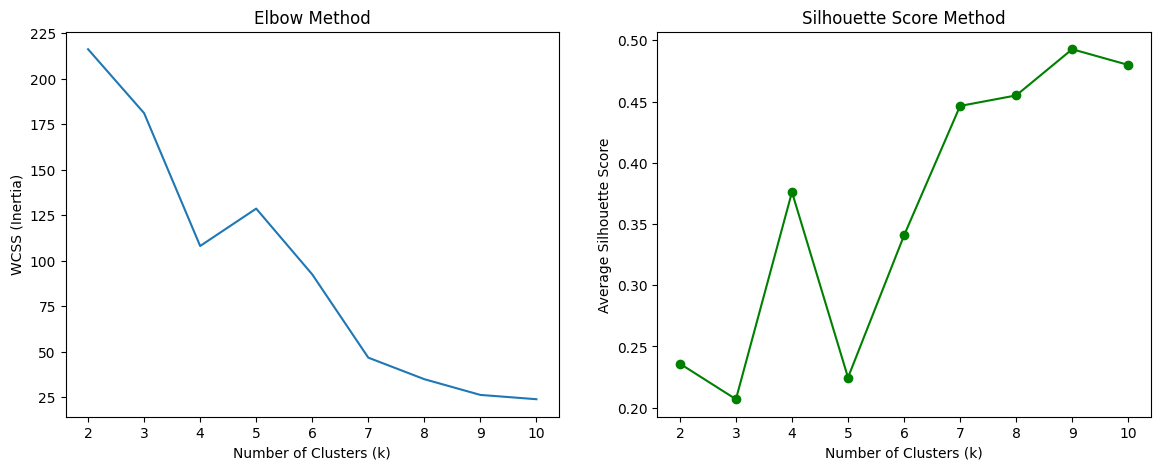

In [13]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



wcss = []
silhouette_scores = []
k_range = range(2, 11)  #

for k in k_range:

    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(data)
    
    wcss.append(kmeans.inertia_)
    
    score = silhouette_score(data, cluster_labels)
    silhouette_scores.append(score)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, wcss)
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)')


ax2.plot(k_range, silhouette_scores, marker='o', color='green')
ax2.set_title('Silhouette Score Method')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Average Silhouette Score')

plt.show()


In [14]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(data)
dx['cluster'] = cluster_labels
dx['cluster'].value_counts().sort_index()

cluster_summary = (dx.groupby('cluster').mean().round(2))

cluster_summary

,total_sessions,avg energy,total_energy,avg_charging_time,avg_total_duration,active_days,sessions_per_day,weekend_ratio,peak_hour_ratio
cluster,,,,,,,,,
0,14190.56,8.57,120131.15,2.08,2.61,2545.56,5.72,0.22,0.76
1,1331.67,8.63,11503.84,2.02,3.47,852.00,1.56,0.25,0.61
2,6889.53,8.46,58330.04,1.89,2.30,1544.94,4.51,0.26,0.81
3,2623.75,10.26,26926.58,2.22,2.50,876.25,2.96,0.17,0.87


In [15]:
for c in sorted(dx['cluster'].unique()):
    print(f"\nCluster {c}")
    print(dx[dx['cluster'] == c].index.tolist())


Cluster 0
[0, 1, 11, 12, 16, 39, 43, 44, 45]

Cluster 1
[17, 18, 19]

Cluster 2
[2, 4, 5, 6, 7, 8, 9, 10, 13, 14, 15, 20, 21, 22, 23, 24, 25]

Cluster 3
[3, 40, 41, 42]


In [16]:
dx['cluster'] = cluster_labels

In [17]:
dx.groupby('cluster').mean().round(2)

,total_sessions,avg energy,total_energy,avg_charging_time,avg_total_duration,active_days,sessions_per_day,weekend_ratio,peak_hour_ratio
cluster,,,,,,,,,
0,14190.56,8.57,120131.15,2.08,2.61,2545.56,5.72,0.22,0.76
1,1331.67,8.63,11503.84,2.02,3.47,852.00,1.56,0.25,0.61
2,6889.53,8.46,58330.04,1.89,2.30,1544.94,4.51,0.26,0.81
3,2623.75,10.26,26926.58,2.22,2.50,876.25,2.96,0.17,0.87


In [19]:
dx['cluster'].value_counts()

cluster
2    17
0     9
3     4
1     3
Name: count, dtype: int64

In [41]:
station_clusters['cluster'] = cluster_labels

In [43]:
station_clusters.head()

,Station Name,total_sessions,avg energy,total_energy,avg_charging_time,avg_total_duration,active_days,sessions_per_day,weekend_ratio,peak_hour_ratio,cluster
0,PALO ALTO CA / BRYANT # 1,13447,7.611354,102349.877624,2.071256,2.602975,2953,4.553674,0.217892,0.759946,0
1,PALO ALTO CA / BRYANT #2,14381,7.455704,107220.474039,2.001734,2.547957,3032,4.743074,0.225228,0.747584,0
2,PALO ALTO CA / BRYANT #3,4472,8.632309,38603.686866,2.002383,2.469606,1406,3.180654,0.225179,0.794275,2
3,PALO ALTO CA / BRYANT #4,3597,10.339060,37189.600000,2.142539,2.421511,1057,3.403027,0.194051,0.867946,3
4,PALO ALTO CA / BRYANT #5,5329,9.138810,48700.719000,1.955917,2.232276,1136,4.691021,0.229311,0.860011,2


In [45]:
for c in sorted(station_clusters['cluster'].unique()):
    print(f"\nCluster {c}")
    print(station_clusters.loc[station_clusters['cluster'] == c,'Station Name'].tolist())


Cluster 0
['PALO ALTO CA / BRYANT # 1', 'PALO ALTO CA / BRYANT #2', 'PALO ALTO CA / HAMILTON #1', 'PALO ALTO CA / HAMILTON #2', 'PALO ALTO CA / HIGH #4', 'PALO ALTO CA / TED THOMPSON #1', 'PALO ALTO CA / WEBSTER #1', 'PALO ALTO CA / WEBSTER #2', 'PALO ALTO CA / WEBSTER #3']

Cluster 1
['PALO ALTO CA / MPL #1', 'PALO ALTO CA / MPL #2', 'PALO ALTO CA / MPL #3']

Cluster 2
['PALO ALTO CA / BRYANT #3', 'PALO ALTO CA / BRYANT #5', 'PALO ALTO CA / BRYANT #6', 'PALO ALTO CA / CAMBRIDGE #1', 'PALO ALTO CA / CAMBRIDGE #2', 'PALO ALTO CA / CAMBRIDGE #3', 'PALO ALTO CA / CAMBRIDGE #4', 'PALO ALTO CA / CAMBRIDGE #5', 'PALO ALTO CA / HIGH #1', 'PALO ALTO CA / HIGH #2', 'PALO ALTO CA / HIGH #3', 'PALO ALTO CA / MPL #4', 'PALO ALTO CA / MPL #5', 'PALO ALTO CA / MPL #6', 'PALO ALTO CA / RINCONADA LIB 1', 'PALO ALTO CA / RINCONADA LIB 2', 'PALO ALTO CA / RINCONADA LIB 3']

Cluster 3
['PALO ALTO CA / BRYANT #4', 'PALO ALTO CA / TED THOMPSON #2', 'PALO ALTO CA / TED THOMPSON #3', 'PALO ALTO CA / TED THO

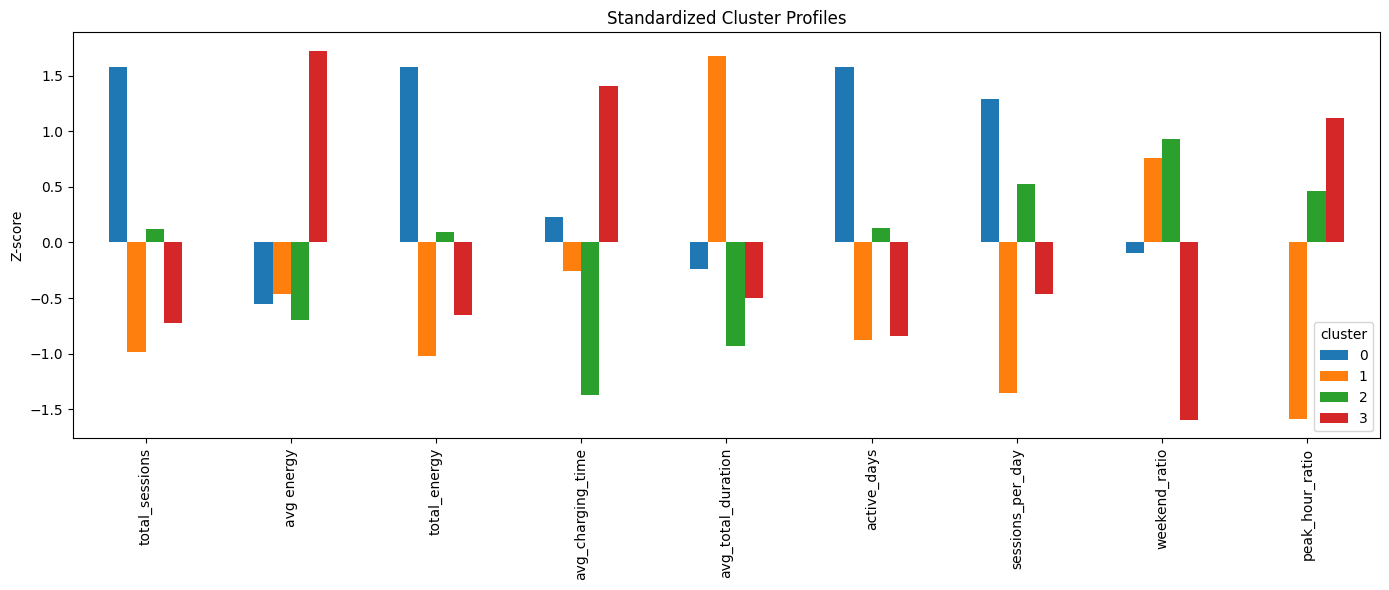

In [49]:
cluster_summary_z = (
    station_clusters
    .drop(columns=['Station Name'])
    .groupby('cluster')
    .mean()
)

from sklearn.preprocessing import StandardScaler

cluster_summary_scaled = pd.DataFrame(
    StandardScaler().fit_transform(cluster_summary_z),
    columns=cluster_summary_z.columns,
    index=cluster_summary_z.index
)

cluster_summary_scaled.T.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title('Standardized Cluster Profiles')
plt.ylabel('Z-score')
plt.tight_layout()
plt.show()

In [51]:
station_clusters.to_csv(
    r'C:\Users\loneo\OneDrive\Documents\ev-charging-demand-segmentation\data\processed/station_clusters.csv',
    index=False
)

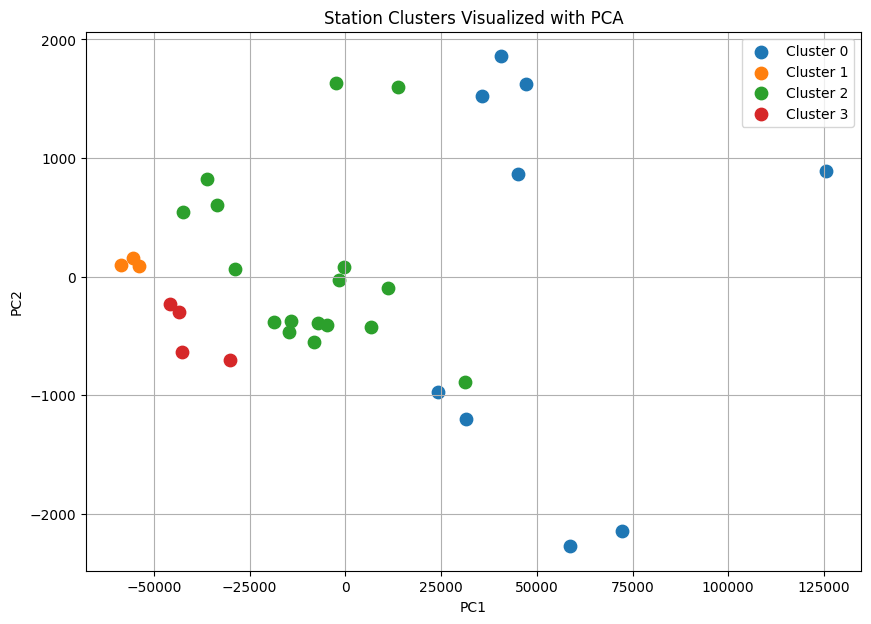

In [53]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Features only
X = station_clusters.drop(columns=['Station Name', 'cluster'])

# PCA to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Add PCA columns for plotting
plot_df = station_clusters.copy()
plot_df['PC1'] = X_pca[:, 0]
plot_df['PC2'] = X_pca[:, 1]

# Plot clusters
plt.figure(figsize=(10, 7))
for c in sorted(plot_df['cluster'].unique()):
    subset = plot_df[plot_df['cluster'] == c]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {c}', s=80)

plt.title('Station Clusters Visualized with PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()